In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from Filters.kalman import KalmanFilter
from Filters.ukf import UnscentedKalmanFilter
from Filters.particle import ParticleFilter
from Filters.ukf_pf import UKF_PF
from Models.lokta_volterra import LotkaVolterraSSM
from Models.lokta_volterra import LotkaVolterraProductSSM

# Code

In [ ]:
import numpy as np
from scipy.stats import skew, kurtosis, wasserstein_distance
from scipy.stats import multivariate_normal
import ot
from scipy.spatial.distance import cdist
from tqdm import tqdm

class SSMDistributionAnalyzer:

    def __init__(self, model, T, N=10000, bins=50, random_seed=42):

        self.model = model
        self.T = T
        self.N = N
        self.bins = bins
        self.random_seed = random_seed

        if random_seed is not None:
            np.random.seed(random_seed)

        self.d = model.d
        self.m = model.m

        self.X_samples = None
        self.Y_samples = None


    # ----------------------------
    # Shannon entropy
    # ----------------------------

    @staticmethod
    def shannon_entropy(p):

        p = p[p > 0]

        return -np.sum(p * np.log(p))


    # ----------------------------
    # Monte Carlo simulation
    # ----------------------------

    def simulate(self):

        X_samples = np.zeros((self.N, self.T + 1, self.d))
        Y_samples = np.zeros((self.N, self.T, self.m))

        i = 0

        with tqdm(total=self.N, desc="Simulating data", unit="sample") as pbar:

            while i < self.N:

                X, Y = self.model.simulate(self.T)

                if np.isfinite(X).all() and np.isfinite(Y).all():

                    X_samples[i] = X
                    Y_samples[i] = Y

                    i += 1
                    pbar.update(1)

        self.X_samples = X_samples
        self.Y_samples = Y_samples


    # ----------------------------
    # Statistics computation
    # ----------------------------
    def compute_statistics(self, samples):

        samples = np.asarray(samples)

        n, dim = samples.shape

        mean = np.mean(samples, axis=0)
        cov = np.cov(samples, rowvar=False)

        cov = np.atleast_2d(cov)

        var = np.diag(cov)

        cov = cov + 1e-8 * np.eye(cov.shape[0])

        skewness = skew(samples, axis=0)
        kurt = kurtosis(samples, axis=0)

        # Histogram density

        hist, edges = np.histogramdd(
            samples,
            bins=self.bins,
            density=True
        )

        p = hist / np.sum(hist)

        entropy = self.shannon_entropy(p.flatten())

        # Gaussian reference

        gauss = multivariate_normal(
            mean=mean,
            cov=np.atleast_2d(cov),
            allow_singular=True
        )

        centers = [
            0.5 * (e[:-1] + e[1:])
            for e in edges
        ]

        mesh = np.meshgrid(*centers, indexing="ij")

        points = np.stack([m.flatten() for m in mesh], axis=-1)

        q = gauss.pdf(points)

        q = q.reshape(hist.shape)

        q = q / np.sum(q)

        kl = np.sum(
            p.flatten()
            * (np.log(p.flatten() + 1e-12) - np.log(q.flatten() + 1e-12))
        )

        # Wasserstein distances
        try:

            gaussian_samples = np.random.multivariate_normal(
                mean,
                np.atleast_2d(cov),
                size=n
            )

            stacked = np.vstack([samples, gaussian_samples])
            m = stacked.mean(axis=0)
            s = stacked.std(axis=0) + 1e-8


            samples_norm = (samples - m)/s
            gaussian_norm = (gaussian_samples - m)/s

            if n > 500:
                subset = np.random.choice(n,500,replace=False)
                samples_norm = samples_norm[subset]
                gaussian_norm = gaussian_norm[subset]
                n = 500

            a = np.ones(n)/n
            b = np.ones(n)/n

            # ---------- W1 ----------
            M1 = cdist(samples_norm, gaussian_norm, metric="euclidean")

            gamma = ot.bregman.sinkhorn_stabilized(
                a,
                b,
                M1,
                reg=0.95,
                numItermax=15000
            )

            W1 = np.sum(gamma * M1)

            # ---------- W2 ----------
            M2 = cdist(samples_norm, gaussian_norm, metric="sqeuclidean")

            gamma = ot.bregman.sinkhorn_stabilized(
                a,
                b,
                M2,
                reg=0.95,
                numItermax=15000
            )

            W2 = np.sqrt(np.sum(gamma * M2))

        except Exception:

            W1 = np.nan
            W2 = np.nan

        return {
            "mean": mean,
            "variance": var,
            "skewness": skewness,
            "kurtosis": kurt,
            "covariance": cov,
            "entropy": entropy,
            "KL_gaussian": kl,
            "wasserstein_W1": W1,
            "wasserstein_W2": W2,
            "histogram": hist,
            "bin_edges": edges
        }


    # Mutual information
    def compute_mutual_information(self):

        mi_list = []

        for t in range(self.T):

            x = self.X_samples[:, t, 0]
            y = self.Y_samples[:, t, 0]

            joint_hist, x_edges, y_edges = np.histogram2d(
                x,
                y,
                bins=self.bins,
                density=True
            )

            pxy = joint_hist / np.sum(joint_hist)

            px = np.sum(pxy, axis=1)
            py = np.sum(pxy, axis=0)

            mi = 0.0

            for i in range(len(px)):
                for j in range(len(py)):

                    if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:

                        mi += pxy[i, j] * np.log(pxy[i, j] / (px[i] * py[j]))

            mi_list.append(mi)

        return mi_list

    # Main analysis
    def analyze(self):

        if self.X_samples is None:
            self.simulate()

        results = {
            "states": [],
            "observations": [],
            "mutual_information": []
        }

        # States
        for t in tqdm(range(self.T + 1), desc="Analyzing states", unit="time step"):
            samples = self.X_samples[:, t, :]
            stats = self.compute_statistics(samples)
            results["states"].append(stats)

        # Observations
        for t in tqdm(range(self.T), desc="Analyzing observations", unit="time step"):
            samples = self.Y_samples[:, t, :]
            stats = self.compute_statistics(samples)
            results["observations"].append(stats)

        # Mutual information
        results["mutual_information"] = self.compute_mutual_information()

        return results
    
    # Visualization
    def plot_wasserstein(self, results):

        W1_states = [s["wasserstein_W1"] for s in results["states"]]
        W2_states = [s["wasserstein_W2"] for s in results["states"]]

        W1_obs = [s["wasserstein_W1"] for s in results["observations"]]
        W2_obs = [s["wasserstein_W2"] for s in results["observations"]]

        plt.figure(figsize=(10,5))

        plt.plot(W1_states, label="W1 states")
        plt.plot(W2_states, label="W2 states")

        plt.plot(W1_obs, "--", label="W1 observations")
        plt.plot(W2_obs, "--", label="W2 observations")

        plt.xlabel("time")
        plt.ylabel("Wasserstein distance")

        plt.title("Distributional deviation from Gaussian approximation")

        plt.legend()
        plt.grid(True)

        plt.show()

    def plot_gaussianity(self, results):
        skew_states = np.array([s["skewness"] for s in results["states"]])
        kurt_states = np.array([s["kurtosis"] for s in results["states"]])

        plt.figure(figsize=(10,5))

        for i in range(skew_states.shape[1]):
            plt.plot(skew_states[:,i], label=f"skew state {i}")

        for i in range(kurt_states.shape[1]):
            plt.plot(kurt_states[:,i], "--", label=f"kurt state {i}")

        plt.axhline(0, color="black", linewidth=1)

        plt.title("Gaussianity diagnostics")
        plt.xlabel("time")

        plt.legend()
        plt.grid(True)

        plt.show()
    
    def plot_entropy(self, results):

        entropy_states = [s["entropy"] for s in results["states"]]
        entropy_obs = [s["entropy"] for s in results["observations"]]

        plt.figure(figsize=(10,5))

        plt.plot(entropy_states, label="states")
        plt.plot(entropy_obs, label="observations")

        plt.xlabel("time")
        plt.ylabel("Shannon entropy")

        plt.title("Entropy evolution")

        plt.legend()
        plt.grid(True)

        plt.show()

    def plot_mutual_information(self, results):

        mi = results["mutual_information"]

        plt.figure(figsize=(10,5))

        plt.plot(mi)

        plt.xlabel("time")
        plt.ylabel("Mutual information")

        plt.title("I(X_t ; Y_t)")

        plt.grid(True)

        plt.show()



    def plot_density_heatmap(self, source="states", dim=0, bins=80):

        if source == "states":
            data = self.X_samples[:, :, dim]
        elif source == "observations":
            data = self.Y_samples[:, :, dim]
        else:
            raise ValueError("source must be 'states' or 'observations'")

        T = data.shape[1]

        heatmap = []
        y_edges = None

        for t in range(T):

            values = data[:, t]

            # rango adaptativo por tiempo
            low, high = np.percentile(values, [1, 99])

            hist, edges = np.histogram(
                values,
                bins=bins,
                range=(low, high),
                density=True
            )

            heatmap.append(hist)

            if y_edges is None:
                y_edges = edges

        heatmap = np.array(heatmap).T

        plt.figure(figsize=(10,6))

        plt.imshow(
            heatmap,
            aspect="auto",
            origin="lower",
            extent=[0, T, y_edges[0], y_edges[-1]],
            cmap="Blues"
        )

        plt.colorbar(label="density")

        plt.xlabel("time")

        if source == "states":
            plt.ylabel(f"state dimension {dim}")
        else:
            plt.ylabel(f"observation dimension {dim}")

        plt.title(f"Temporal density heatmap ({source})")

        plt.show()

    def plot_snapshot_distribution(self, t, source="states", dims=(0,), bins=40):
        """
        Plot distribution snapshot at fixed time.

        Parameters
        ----------
        t : int
            Time index.

        source : {"states","observations"}
            Variable to visualize.

        dims : tuple
            Dimensions to plot.

        bins : int
            Histogram bins.
        """

        if source == "states":
            data = self.X_samples[:, t, :]
            label = "state"
        elif source == "observations":
            data = self.Y_samples[:, t, :]
            label = "observation"
        else:
            raise ValueError("source must be 'states' or 'observations'")

        dims = tuple(dims)

        if len(dims) == 1:

            d = dims[0]
            values = data[:, d]

            plt.figure(figsize=(6,4))

            plt.hist(values, bins=bins, density=True, alpha=0.7)

            plt.xlabel(f"{label} dimension {d}")
            plt.ylabel("density")
            plt.title(f"{label} distribution at time t={t}")

            plt.grid(True)
            plt.show()

        elif len(dims) == 2:

            d1, d2 = dims

            x = data[:, d1]
            y = data[:, d2]

            plt.figure(figsize=(6,5))

            plt.hist2d(x, y, bins=bins, density=True, cmap="Blues")

            plt.xlabel(f"{label} dimension {d1}")
            plt.ylabel(f"{label} dimension {d2}")

            plt.title(f"{label} joint distribution at time t={t}")

            plt.colorbar(label="density")

            plt.show()

        else:

            raise ValueError("dims must have length 1 or 2")

# Lokta-Volterra Gaussian state space model

## Experiment 0: Statistical characterization of the state space model

In [ ]:
model = LotkaVolterraProductSSM(dt=0.01, mean_log=np.array([3.0, 3.0]), cov_log=0.15 * np.eye(2), Sigma=5e-4 * np.eye(2), sigma_obs=1.0)

analyzer = SSMDistributionAnalyzer(
    model,
    T=50,
    N=100,
    bins=20
)

results = analyzer.analyze()


Simulating data:   0%|          | 0/100 [00:01<?, ?sample/s]

KeyboardInterrupt



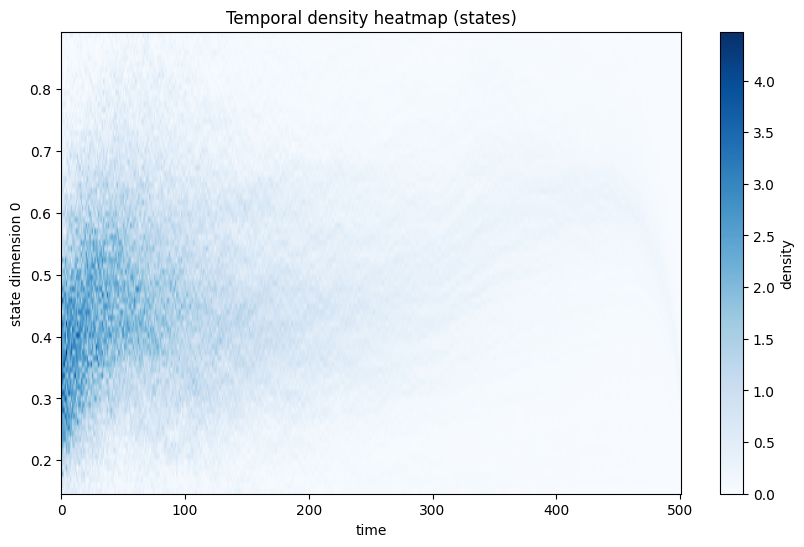

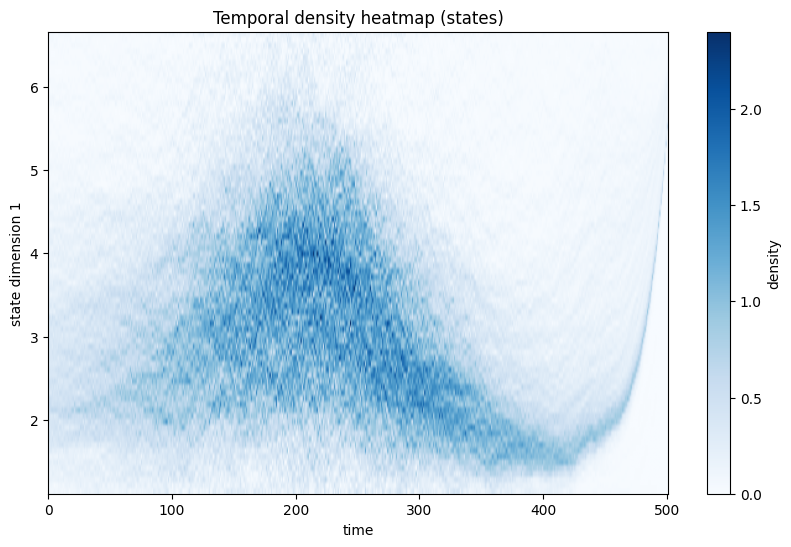

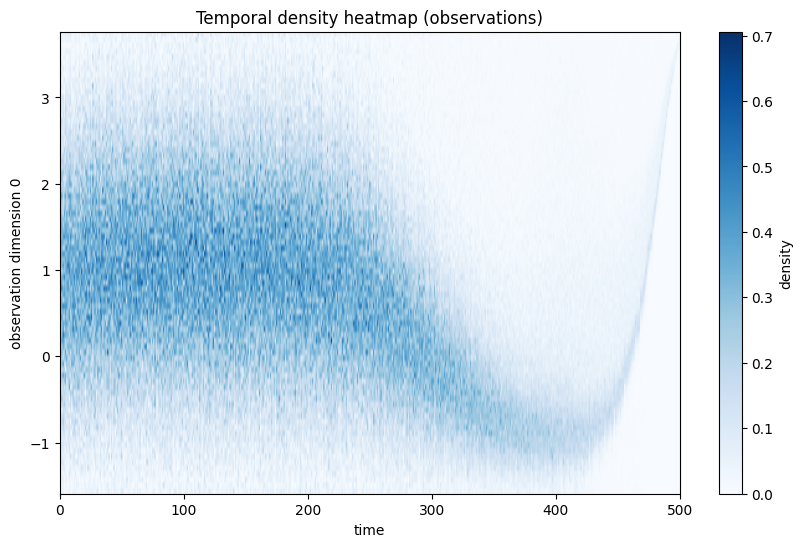

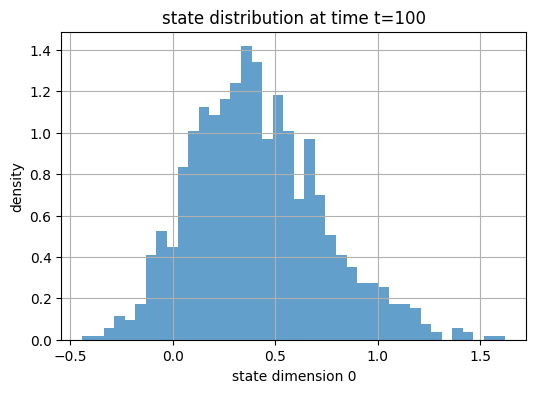

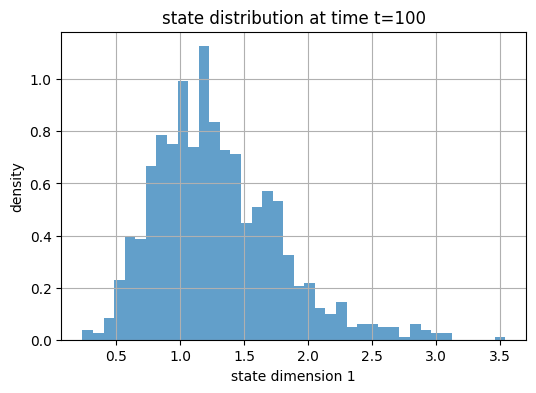

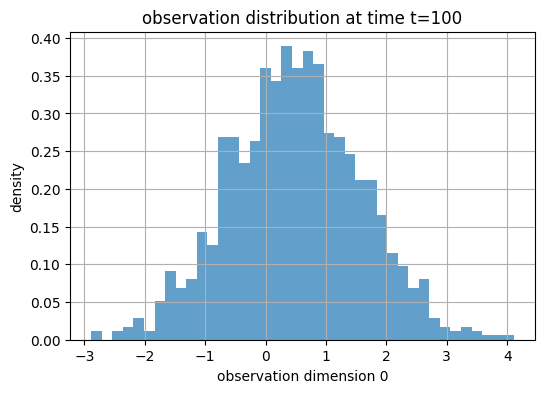

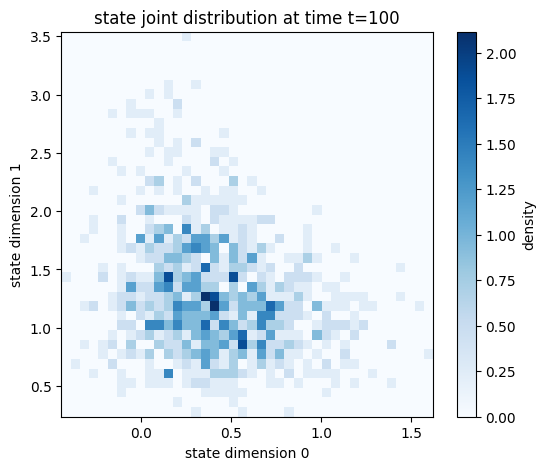

In [163]:
#analyzer.plot_wasserstein(results)

#analyzer.plot_gaussianity(results)

#analyzer.plot_entropy(results)

#analyzer.plot_mutual_information(results)


analyzer.plot_density_heatmap(source="states", dim=0)
analyzer.plot_density_heatmap(source="states", dim=1)


analyzer.plot_density_heatmap(source="observations", dim=0)

analyzer.plot_snapshot_distribution(
    t=100,
    source="states",
    dims=(0,)
)
analyzer.plot_snapshot_distribution(
    t=100,
    source="states",
    dims=(1,)
)

analyzer.plot_snapshot_distribution(
    t=100,
    source="observations",
    dims=(0,)
)

analyzer.plot_snapshot_distribution(
    t=100,
    source="states",
    dims=(0,1)
)

#analyzer.plot_snapshot_distribution(
#    t=20,
#    source="observations",
#    dims=(0,1)
#)

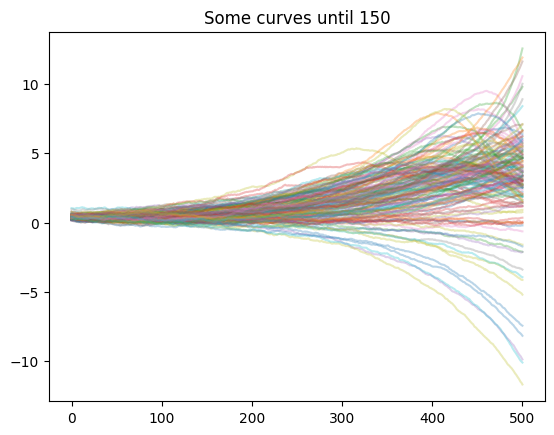

In [166]:
lim = 150
for i in range(lim):
    plt.plot(analyzer.X_samples[i,:,0],alpha=0.3)
plt.title(f"Some curves until {lim}")
plt.show()

## Experiment 1: Hyperparameter selection

In [ ]:
import numpy as np
import pandas as pd
import itertools
import time
from tqdm import tqdm

from scipy.stats import entropy
from scipy.spatial.distance import cdist
import ot


class HybridFilterHyperparameterStudy:

    def __init__(
        self,
        model,
        reference_particles=50000,
        R=5,
        random_seed=42
    ):

        self.model = model
        self.reference_particles = reference_particles
        self.R = R

        if random_seed is not None:
            np.random.seed(random_seed)

        self.reference_filter = None
        self.dataset = None

    def simulate_dataset(self, T):

        X_true, Y = self.model.simulate(T)

        self.dataset = {
            "X_true": X_true,
            "Y": Y
        }

        return X_true, Y

    def run_reference_filter(self):

        X_true = self.dataset["X_true"]
        Y = self.dataset["Y"]

        ref_filter = BootstrapParticleFilter(
            self.model,
            N=self.reference_particles
        )

        ref_filter.filter(Y)

        self.reference_filter = ref_filter


    @staticmethod
    def wasserstein_distance(x, y):

        n = len(x)

        a = np.ones(n) / n
        b = np.ones(n) / n

        M1 = cdist(x, y, metric="euclidean")
        M2 = cdist(x, y, metric="sqeuclidean")

        W1 = ot.sinkhorn2(a, b, M1, reg=1.0)
        W2 = np.sqrt(ot.sinkhorn2(a, b, M2, reg=1.0))

        return W1, W2


    def evaluate_configuration(self, L, N):

        X_true = self.dataset["X_true"]
        Y = self.dataset["Y"]

        rmse_list = []
        mae_list = []
        time_list = []
        W1_list = []
        W2_list = []

        for r in range(self.R):

            filt = UKF_PF(self.model, L=L, N=N)

            start = time.perf_counter()
            filt.filter(Y)
            end = time.perf_counter()

            elapsed = end - start

            rmse = filt.rmse_total(X_true)
            mae = np.mean(filt.mae(X_true))

            rmse_list.append(rmse)
            mae_list.append(mae)
            time_list.append(elapsed)

            # distribución final
            particles_h = filt.get_particles()
            particles_ref = self.reference_filter.get_particles()

            W1, W2 = self.wasserstein_distance(
                particles_h,
                particles_ref
            )

            W1_list.append(W1)
            W2_list.append(W2)

        rmse_mean = np.mean(rmse_list)
        time_mean = np.mean(time_list)

        efficiency = rmse_mean / time_mean

        return {

            "L": L,
            "N": N,

            "RMSE": rmse_mean,
            "RMSE_var": np.var(rmse_list),

            "MAE": np.mean(mae_list),

            "W1": np.mean(W1_list),
            "W2": np.mean(W2_list),

            "Time": time_mean,

            "Efficiency": efficiency
        }
    
    def run_grid(
        self,
        L_values=[5,10,20,40],
        N_values=[500,1000,5000,10000]
        ):

        results = []

        grid = list(itertools.product(L_values, N_values))

        for L, N in tqdm(grid, desc="Hyperparameter search"):

            metrics = self.evaluate_configuration(L, N)

            results.append(metrics)

        df = pd.DataFrame(results)

        best_idx = df["Efficiency"].idxmin()

        best_config = df.loc[best_idx]

        return df, best_config

In [ ]:
study = HybridFilterHyperparameterStudy(
    model,
    reference_particles=50000,
    R=5
)
study.simulate_dataset(T=300)
study.run_reference_filter()
df, best = study.run_grid()
print(best)

## Experiment 2: Comparison with baseline filters

In [ ]:
import numpy as np
import pandas as pd
import time
from tqdm import tqdm

from scipy.spatial.distance import cdist
from scipy.stats import entropy
import ot

class FilterComparisonExperiment:

    def __init__(
        self,
        model,
        T,
        reference_particles=50000,
        pf_particles=2000,
        L_r=10,
        R=5,
        random_seed=42
    ):

        self.model = model
        self.T = T

        self.reference_particles = reference_particles
        self.pf_particles = pf_particles
        self.L_r = L_r

        self.R = R

        if random_seed is not None:
            np.random.seed(random_seed)

        self.dataset = None
        self.reference_filter = None

    def simulate_dataset(self):

        X_true, Y = self.model.simulate(self.T)

        self.dataset = {
            "X_true": X_true,
            "Y": Y
        }

        return X_true, Y
    
    def run_reference_filter(self):

        Y = self.dataset["Y"]

        pf_ref = ParticleFilter(
            self.model,
            N=self.reference_particles
        )

        pf_ref.filter(Y)

        self.reference_filter = pf_ref


    @staticmethod
    def rmse(x_hat, x_true):

        return np.sqrt(np.mean((x_hat - x_true) ** 2))

    @staticmethod
    def mae(x_hat, x_true):

        return np.mean(np.abs(x_hat - x_true))
    
    @staticmethod
    def wasserstein(x, y):

        n = min(len(x), len(y))

        x = x[:n]
        y = y[:n]

        a = np.ones(n) / n
        b = np.ones(n) / n

        M1 = cdist(x, y, metric="euclidean")
        M2 = cdist(x, y, metric="sqeuclidean")

        W1 = ot.sinkhorn2(a, b, M1, reg=1.0)
        W2 = np.sqrt(ot.sinkhorn2(a, b, M2, reg=1.0))

        return W1, W2
    
    @staticmethod
    def kl_divergence(p_samples, q_samples, bins=50):

        hist_p, edges = np.histogramdd(p_samples, bins=bins, density=True)
        hist_q, _ = np.histogramdd(q_samples, bins=edges, density=True)

        p = hist_p.flatten() + 1e-12
        q = hist_q.flatten() + 1e-12

        p /= p.sum()
        q /= q.sum()

        return entropy(p, q)


    def run_single_filter(self, name):

        Y = self.dataset["Y"]

        if name == "KF":
            filt = KalmanFilter(self.model)

        elif name == "UKF":
            filt = UnscentedKalmanFilter(self.model)

        elif name == "PF":
            filt = ParticleFilter(self.model, N=self.pf_particles)

        elif name == "BF":
            filt = UKF_PF(
                self.model,
                L=self.L_r,
                N=self.pf_particles
            )

        else:
            raise ValueError("Unknown filter")

        start = time.perf_counter()
        res = filt.filter(Y)
        end = time.perf_counter()

        runtime = end - start

        return filt, res, runtime


    def evaluate_filter(self, name):

        X_true = self.dataset["X_true"]

        filt, res, runtime = self.run_single_filter(name)

        x_hat = res["filtering_mean"]

        rmse = self.rmse(x_hat, X_true[-1])
        mae = self.mae(x_hat, X_true[-1])

        particles_ref = self.reference_filter.get_particles()

        try:
            particles = filt.get_particles()

            W1, W2 = self.wasserstein(
                particles,
                particles_ref
            )

            KL = self.kl_divergence(
                particles,
                particles_ref
            )

        except:

            W1, W2, KL = np.nan, np.nan, np.nan

        return {

            "method": name,

            "RMSE": rmse,
            "MAE": mae,

            "W1": W1,
            "W2": W2,
            "KL": KL,

            "Time": runtime,

            "Efficiency_W1": W1 / runtime if runtime > 0 else np.nan
        }
    
    def run_single_experiment(self):

        methods = ["KF", "UKF", "PF", "BF"]

        results = []

        for m in methods:

            metrics = self.evaluate_filter(m)

            results.append(metrics)

        return pd.DataFrame(results)
    

    def run_monte_carlo(self):

        all_results = []

        for r in tqdm(range(self.R), desc="Monte Carlo"):

            self.simulate_dataset()

            self.run_reference_filter()

            df = self.run_single_experiment()

            df["run"] = r

            all_results.append(df)

        df_all = pd.concat(all_results)

        return df_all


    def summarize_results(self, df):

        summary = df.groupby("method").agg(

            RMSE_mean=("RMSE", "mean"),
            RMSE_std=("RMSE", "std"),

            MAE_mean=("MAE", "mean"),

            W1_mean=("W1", "mean"),
            W2_mean=("W2", "mean"),

            KL_mean=("KL", "mean"),

            Time_mean=("Time", "mean")

        )

        return summary
    



experiment = FilterComparisonExperiment(
    model,
    T=300,
    reference_particles=50000,
    pf_particles=2000,
    L_r=10,
    R=10
)

df = experiment.run_monte_carlo()

summary = experiment.summarize_results(df)

print(summary)

## Experiment 3: Convergence of bootstrap particle filter from a Gaussian approximation

In [ ]:
import numpy as np
import pandas as pd
import time
from tqdm import tqdm

from scipy.spatial.distance import cdist
import ot



class PFConvergenceExperiment:

    def __init__(
        self,
        model,
        T,
        reference_particles=50000,
        test_particles=1000,
        epsilon=0.1,
        R=5,
        random_seed=42
    ):

        self.model = model
        self.T = T

        self.reference_particles = reference_particles
        self.test_particles = test_particles

        self.epsilon = epsilon
        self.R = R

        if random_seed is not None:
            np.random.seed(random_seed)

        self.dataset = None
        self.reference_filter = None

    def simulate_dataset(self):

        X_true, Y = self.model.simulate(self.T)

        self.dataset = {
            "X_true": X_true,
            "Y": Y
        }

        return X_true, Y
    

    def run_reference_filter(self):

        Y = self.dataset["Y"]

        pf_ref = ParticleFilter(
            self.model,
            N=self.reference_particles
        )

        pf_ref.filter(Y)

        self.reference_filter = pf_ref


    def run_test_filter(self):

        Y = self.dataset["Y"]

        pf = ParticleFilter(
            self.model,
            N=self.test_particles
        )

        pf.filter(Y)

        return pf


    @staticmethod
    def wasserstein(x, y):

        n = min(len(x), len(y))

        x = x[:n]
        y = y[:n]

        a = np.ones(n) / n
        b = np.ones(n) / n

        M1 = cdist(x, y, metric="euclidean")
        M2 = cdist(x, y, metric="sqeuclidean")

        W1 = ot.sinkhorn2(a, b, M1, reg=1.0)
        W2 = np.sqrt(ot.sinkhorn2(a, b, M2, reg=1.0))

        return W1, W2


    def compute_distances(self, pf):

        ref_particles = self.reference_filter.particles_history
        test_particles = pf.particles_history

        W1 = []
        W2 = []

        for k in range(len(ref_particles)):

            p_ref = ref_particles[k]
            p_test = test_particles[k]

            w1, w2 = self.wasserstein(p_test, p_ref)

            W1.append(w1)
            W2.append(w2)

        return np.array(W1), np.array(W2)

    def convergence_time(self, W2):

        for k, val in enumerate(W2):

            if val < self.epsilon:
                return k

        return np.nan


    def run_single_experiment(self):

        self.simulate_dataset()

        self.run_reference_filter()

        pf = self.run_test_filter()

        W1, W2 = self.compute_distances(pf)

        tau = self.convergence_time(W2)

        return {

            "W1": W1,
            "W2": W2,
            "tau_conv": tau
        }
    

    def run_monte_carlo(self):

        results = []

        W1_all = []
        W2_all = []

        for r in tqdm(range(self.R), desc="Monte Carlo"):

            res = self.run_single_experiment()

            results.append(res["tau_conv"])

            W1_all.append(res["W1"])
            W2_all.append(res["W2"])

        return {

            "tau_conv": np.array(results),
            "W1": np.array(W1_all),
            "W2": np.array(W2_all)
        }


    @staticmethod
    def summarize(results):

        tau = results["tau_conv"]

        summary = {

            "tau_mean": np.nanmean(tau),
            "tau_std": np.nanstd(tau),
            "tau_median": np.nanmedian(tau),
            "P_converged": np.mean(~np.isnan(tau))

        }

        return summary






experiment = PFConvergenceExperiment(
    model,
    T=200,
    reference_particles=50000,
    test_particles=1000,
    epsilon=0.05,
    R=20    
)

results = experiment.run_monte_carlo()

summary = experiment.summarize(results)

print(summary)

## Experiment 4: Control error

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.spatial.distance import cdist
import ot

class ErrorControlExperiment:

    def __init__(
        self,
        model,
        T,
        reference_particles=50000,
        checkpoint_particles=2000,
        L_r=10,
        R=5,
        random_seed=42
    ):

        self.model = model
        self.T = T

        self.reference_particles = reference_particles
        self.checkpoint_particles = checkpoint_particles
        self.L_r = L_r

        self.R = R

        if random_seed is not None:
            np.random.seed(random_seed)

        self.dataset = None
        self.reference_filter = None

    def simulate_dataset(self):

        X_true, Y = self.model.simulate(self.T)

        self.dataset = {
            "X_true": X_true,
            "Y": Y
        }

        return X_true, Y
    

    def run_reference_filter(self):

        Y = self.dataset["Y"]

        pf_ref = ParticleFilter(
            self.model,
            N=self.reference_particles
        )

        pf_ref.filter(Y)

        self.reference_filter = pf_ref


    def run_hybrid_filter(self):

        Y = self.dataset["Y"]

        bf = UKF_PF(
            self.model,
            L=self.L_r,
            N=self.checkpoint_particles
        )

        bf.filter(Y)

        return bf
    
    @staticmethod
    def wasserstein(x, y):

        n = min(len(x), len(y))

        x = x[:n]
        y = y[:n]

        a = np.ones(n) / n
        b = np.ones(n) / n

        M = cdist(x, y, metric="sqeuclidean")

        W2 = np.sqrt(
            ot.sinkhorn2(a, b, M, reg=1.0)
        )

        return W2


    def compute_error_sequence(self, hybrid_filter):

        ref_particles = self.reference_filter.particles_history
        hybrid_particles = hybrid_filter.particles_history

        W2 = []

        for k in range(len(ref_particles)):

            p_ref = ref_particles[k]
            p_h = hybrid_particles[k]

            w = self.wasserstein(p_h, p_ref)

            W2.append(w)

        return np.array(W2)


    @staticmethod
    def estimate_rho(W2):

        ratios = []

        for k in range(1, len(W2)):

            if W2[k-1] > 0:
                ratios.append(W2[k] / W2[k-1])

        return np.nanmedian(ratios)
    

    def theoretical_bound(self, W2, rho):

        e0 = W2[0]

        eps = np.nanmax(W2) * 0.1  # estimación empírica

        bound = []

        for k in range(len(W2)):

            val = (rho**k) * e0 + eps / (1 - rho)

            bound.append(val)

        return np.array(bound)
    

    def run_single_experiment(self):

        self.simulate_dataset()

        self.run_reference_filter()

        hybrid = self.run_hybrid_filter()

        W2 = self.compute_error_sequence(hybrid)

        rho = self.estimate_rho(W2)

        bound = self.theoretical_bound(W2, rho)

        return {

            "W2": W2,
            "bound": bound,
            "rho": rho
        }
    

    def run_monte_carlo(self):

        W2_all = []
        bounds_all = []
        rhos = []

        for r in tqdm(range(self.R), desc="Monte Carlo"):

            res = self.run_single_experiment()

            W2_all.append(res["W2"])
            bounds_all.append(res["bound"])
            rhos.append(res["rho"])

        return {

            "W2": np.array(W2_all),
            "bounds": np.array(bounds_all),
            "rho": np.array(rhos)
        }
    
    @staticmethod
    def summarize(results):

        rho = results["rho"]

        return {

            "rho_mean": np.mean(rho),
            "rho_std": np.std(rho),
            "rho_median": np.median(rho)

        }
    


experiment = ErrorControlExperiment(
    model,
    T=200,
    reference_particles=50000,
    checkpoint_particles=2000,
    L_r=10,
    R=10
)

results = experiment.run_monte_carlo()

summary = experiment.summarize(results)

print(summary)

# Lokta-Volterra non Gaussian state space model